# Complementaria Semana 15: Réplicas independientes, corrida larga y batch means

Este notebook desarrolla los conceptos centrales del **análisis de salidas de simulación** para un sistema de colas M/M/c, abordando dos estrategias complementarias:

- **Réplicas independientes:** múltiples corridas cortas con semillas distintas, que producen observaciones i.i.d. sobre las cuales se aplica inferencia clásica.
- **Corrida larga con batch means:** una sola corrida extensa, de la que se descarta el período transitorio (warm-up) y se divide el resto en lotes para estimar el régimen estacionario del sistema.

Ambos enfoques buscan el mismo objetivo: convertir resultados estocásticos de simulación en **estimaciones cuantificadas con garantías estadísticas de confianza**. La diferencia está en cuándo conviene usar cada uno, y eso depende del tipo de sistema y de la pregunta de investigación.

El modelo de referencia a lo largo del notebook es el sistema **M/M/c** (colas de Erlang con $c$ servidores en paralelo), que permite comparar los resultados simulados con valores teóricos exactos.

## Introducción

Una simulación de eventos discretos es, en esencia, un **experimento estadístico computacional**. Cada corrida del modelo produce una realización aleatoria de las métricas de interés —tiempos de espera, utilización, longitud de cola— y, como en cualquier experimento, una sola observación no es suficiente para hacer inferencias confiables sobre el sistema.

Este notebook aborda ese problema desde dos ángulos complementarios:

### 1. Réplicas independientes
La estrategia más directa: correr el modelo $R$ veces con semillas distintas, de modo que las salidas de cada réplica sean observaciones **i.i.d.** Esto permite aplicar el Teorema Central del Límite (TCL) directamente y construir intervalos de confianza con la distribución $t$ de Student. Esta sección cubre la teoría de réplicas, la varianza entre corridas, la construcción formal de ICs y la determinación del número mínimo de réplicas para una precisión deseada.

### 2. Corrida larga, warm-up y batch means
Cuando interesa el **régimen estacionario** de un sistema que opera continuamente, las réplicas independientes tienen una limitación: cada corrida arranca desde el estado inicial (sistema vacío) y atraviesa un período transitorio antes de estabilizarse. Si se hacen $R$ réplicas, se incurre $R$ veces en ese costo de calentamiento.

La alternativa es ejecutar **una sola corrida muy larga**, descartar el período transitorio una única vez (warm-up) e identificar ese punto visualmente mediante una media móvil sobre la trayectoria $N(t)$. Luego, el intervalo estacionario se divide en $B$ lotes (batch means) que se tratan como observaciones aproximadamente independientes. Con $B \geq 20$–$30$ lotes suficientemente grandes, el TCL aplica nuevamente y se construye un IC con $B - 1$ grados de libertad.

Un supuesto crítico de este método es que los lotes sean **aproximadamente independientes**, lo cual se verifica calculando la autocorrelación de orden 1 entre medias de lote: se busca $|r_1| < 0.3$, y preferiblemente $|r_1| < 0.1$.

### Comparación de enfoques
Ambas estrategias se comparan directamente sobre el mismo modelo M/M/c, analizando la precisión obtenida (semiancho del IC) bajo distintos presupuestos de tiempo simulado. La elección entre ellas depende del tipo de sistema, del objetivo del análisis y del costo computacional disponible.

## Objetivos de aprendizaje

Al finalizar este notebook, el estudiante debería poder:

**Réplicas independientes:**
1. Explicar por qué se usan réplicas independientes en simulación y cuáles son sus fundamentos estadísticos.
2. Calcular e interpretar la varianza muestral entre réplicas de una simulación.
3. Construir intervalos de confianza para estimadores de simulación usando la distribución $t$ de Student.
4. Determinar el número de réplicas necesario para alcanzar una precisión relativa o absoluta especificada.
5. Comparar resultados simulados con valores teóricos de referencia usando herramientas estadísticas formales.

**Corrida larga, warm-up y batch means:**

6. Identificar visualmente el período de warm-up a partir de la trayectoria $N(t)$ suavizada con media móvil.
7. Explicar por qué se construye una grilla regular, se interpola $N(t)$ y se aplica media móvil para detectar el transitorio.
8. Implementar el método de batch means y calcular un IC a partir de los promedios de lote.
9. Validar la independencia entre lotes mediante la autocorrelación lag-1 ($r_1$) e interpretar el resultado.
10. Elegir un número adecuado de lotes $B$ justificando la aplicabilidad del TCL (mínimo, óptimo, máximo práctico).
11. Comparar el desempeño de réplicas independientes vs. batch means bajo el mismo presupuesto de tiempo simulado y argumentar cuándo conviene cada enfoque.

## Fundamentos teóricos: réplicas independientes en simulación

### ¿Por qué son necesarias las réplicas?

Considere una métrica de interés $\theta$, por ejemplo el tiempo promedio en cola $W_q$. Una sola corrida de simulación de duración $T$ produce un estimador:

$$
\hat{\theta} = \frac{1}{n} \sum_{i=1}^{n} X_i
$$

donde $X_i$ es la observación del cliente $i$ (por ejemplo, su tiempo de espera) y $n$ es el número de clientes atendidos.

El problema es que este estimador tiene **variabilidad aleatoria**: si se repitiera la misma corrida con una semilla diferente, se obtendría un valor distinto. Para cuantificar esa variabilidad se requiere más de una observación del estimador, es decir, más de una réplica.

### El modelo estadístico de las réplicas

Sea $Y_j$ el valor de la métrica de interés en la réplica $j$, para $j = 1, 2, \ldots, R$. Si las réplicas se ejecutan con semillas independientes:

$$
Y_1, Y_2, \ldots, Y_R \overset{\text{i.i.d.}}{\sim} F(\theta, \sigma^2)
$$

donde $F$ es una distribución con media $\theta$ (el parámetro verdadero) y varianza $\sigma^2$ (variabilidad natural del sistema).

El estimador natural de $\theta$ es la media muestral:

$$
\bar{Y} = \frac{1}{R} \sum_{j=1}^{R} Y_j
$$

que es **insesgado** ($\mathbb{E}[\bar{Y}] = \theta$) y tiene varianza:

$$
\text{Var}(\bar{Y}) = \frac{\sigma^2}{R}
$$

### El Teorema Central del Límite como fundamento

Gracias al Teorema Central del Límite (TCL), para $R$ suficientemente grande:

$$
\frac{\bar{Y} - \theta}{S / \sqrt{R}} \xrightarrow{d} t_{R-1}
$$

donde $S^2 = \frac{1}{R-1} \sum_{j=1}^{R} (Y_j - \bar{Y})^2$ es la varianza muestral entre réplicas y $t_{R-1}$ es la distribución $t$ de Student con $R-1$ grados de libertad.

Este resultado es clave: **permite hacer inferencia estadística clásica sobre las salidas de simulación**, tratando cada réplica como una observación independiente.

> **Nota importante:** El TCL se aplica al promedio entre réplicas, no a las observaciones individuales dentro de una réplica. Dentro de una sola corrida, las observaciones (tiempos de espera de clientes sucesivos) están correlacionadas, por lo que no se puede aplicar directamente el TCL a ellas.

## Modelo de simulación extendido: M/M/c

Para este notebook se extenderá el modelo base M/M/1 a un sistema **M/M/c** con $c$ servidores en paralelo. Esta extensión hace más ricos los análisis de varianza y eficiencia estadística.

### Supuestos del modelo M/M/c

1. Las llegadas siguen un proceso de Poisson con tasa $\lambda$.
2. Los tiempos de servicio son exponenciales con parámetro $\mu$ (por servidor).
3. Existen $c$ servidores idénticos en paralelo.
4. La cola tiene capacidad infinita y disciplina FIFO.
5. No hay abandono ni prioridades.
6. El sistema inicia vacío.
7. La condición de estabilidad es $\rho = \lambda / (c \cdot \mu) < 1$.

### Fórmulas teóricas M/M/c

Para el modelo M/M/c estable, se definen:

$$
\rho = \frac{\lambda}{c \cdot \mu}, \quad a = \frac{\lambda}{\mu}
$$

La probabilidad de que el sistema esté vacío es:

$$
P_0 = \left[ \sum_{n=0}^{c-1} \frac{a^n}{n!} + \frac{a^c}{c!} \cdot \frac{1}{1-\rho} \right]^{-1}
$$

El número promedio en cola:

$$
L_q = \frac{P_0 \cdot a^c \cdot \rho}{c! \cdot (1-\rho)^2}
$$

Y por la Ley de Little ($L = \lambda W$):

$$
W_q = \frac{L_q}{\lambda}, \quad W = W_q + \frac{1}{\mu}, \quad L = \lambda W
$$

## Implementación

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import simpy
import random
import statistics
import math
import warnings
warnings.filterwarnings('ignore')

# Estilo consistente para todas las figuras
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

Este bloque importa las librerías principales del notebook. `numpy` y `scipy` se usarán para cálculos estadísticos, `pandas` para organizar resultados, `matplotlib` para visualización, `simpy` y `random` para la simulación de eventos discretos, y `math` para las fórmulas teóricas del modelo M/M/c.

### Función de simulación M/M/c

Se reutiliza la estructura del modelo M/M/1 de complementarias anteriores, extendida para soportar $c$ servidores y con registro de métricas por réplica.

In [2]:
def simular_mmc(lam=3.0, mu=2.0, c=2, T=5_000, seed=42):
    """
    Simula un sistema M/M/c durante un horizonte de tiempo T.
    
    Parámetros
    ----------
    lam  : tasa de llegadas (clientes por unidad de tiempo)
    mu   : tasa de servicio por servidor (clientes por unidad de tiempo)
    c    : número de servidores en paralelo
    T    : horizonte de simulación (unidades de tiempo)
    seed : semilla para reproducibilidad
    
    Retorna
    -------
    dict con métricas estimadas de la réplica
    """
    rho = lam / (c * mu)
    if rho >= 1:
        print(f"ADVERTENCIA: ρ = {rho:.3f} >= 1. Sistema inestable.")
    
    random.seed(seed)
    env = simpy.Environment()
    servidores = simpy.Resource(env, capacity=c)
    
    # Monitor de métricas
    mon = {
        "arrivals": 0,
        "departures": 0,
        "busy_time": 0.0,
        "waits": [],
        "system_times": [],
        "service_times": []
    }
    
    def cliente(env, cid):
        t_llegada = env.now
        with servidores.request() as req:
            yield req
            t_inicio = env.now
            espera = t_inicio - t_llegada
            t_serv = random.expovariate(mu)
            mon["busy_time"] += t_serv
            yield env.timeout(t_serv)
            t_fin = env.now
        
        mon["waits"].append(espera)
        mon["system_times"].append(t_fin - t_llegada)
        mon["service_times"].append(t_serv)
        mon["departures"] += 1
    
    def generador(env):
        i = 0
        while True:
            yield env.timeout(random.expovariate(lam))
            i += 1
            mon["arrivals"] += 1
            env.process(cliente(env, i))
    
    env.process(generador(env))
    env.run(until=T)
    
    # Métricas de la réplica
    n = mon["departures"]
    Wq = statistics.mean(mon["waits"]) if mon["waits"] else 0.0
    W  = statistics.mean(mon["system_times"]) if mon["system_times"] else 0.0
    util = mon["busy_time"] / (c * T)
    lambda_ef = n / T
    Lq = lambda_ef * Wq
    L  = lambda_ef * W
    
    return {
        "n_clientes": n,
        "Wq": Wq,
        "W": W,
        "Lq": Lq,
        "L": L,
        "utilizacion": util
    }

### Cálculo de valores teóricos M/M/c

Para validar los resultados simulados, se implementan las fórmulas exactas de Erlang-C para el modelo M/M/c.

In [3]:
def teoria_mmc(lam, mu, c):
    """
    Calcula métricas teóricas exactas del modelo M/M/c usando las fórmulas de Erlang-C.
    
    Retorna dict con P0, Lq, L, Wq, W, rho.
    """
    rho = lam / (c * mu)
    a   = lam / mu  # carga ofrecida
    
    if rho >= 1:
        return {k: float('nan') for k in ["P0", "Lq", "L", "Wq", "W", "rho"]}
    
    # Suma de la serie para P0
    suma = sum((a**n) / math.factorial(n) for n in range(c))
    suma += (a**c) / (math.factorial(c) * (1 - rho))
    P0 = 1.0 / suma
    
    # Fórmula de Erlang-C
    C = (a**c / (math.factorial(c) * (1 - rho))) * P0  # P(esperar) = C(c, a)
    
    Lq = C * rho / (1 - rho)
    Wq = Lq / lam
    W  = Wq + 1.0 / mu
    L  = lam * W
    
    return {
        "P0": round(P0, 6),
        "C_erlang": round(C, 6),  # probabilidad de esperar
        "Lq": round(Lq, 6),
        "L": round(L, 6),
        "Wq": round(Wq, 6),
        "W": round(W, 6),
        "rho": round(rho, 6)
    }

# Parámetros base del experimento
LAM = 3.0   # tasa de llegadas
MU  = 2.0   # tasa de servicio por servidor
C   = 2     # número de servidores
T   = 5_000 # horizonte por réplica

teo = teoria_mmc(LAM, MU, C)
print("Valores teóricos M/M/c:")
pd.Series(teo)

Valores teóricos M/M/c:


P0          0.142857
C_erlang    0.642857
Lq          1.928571
L           3.428571
Wq          0.642857
W           1.142857
rho         0.750000
dtype: float64

Con $\lambda = 3$, $\mu = 2$ y $c = 2$ servidores, la utilización por servidor es $\rho = \lambda/(c\mu) = 0.75$, lo que garantiza un sistema estable con valores teóricos bien definidos. Estos servirán como referencia para la validación estadística de las réplicas.

### Corrida piloto: verificación del modelo extendido

Antes de ejecutar el experimento completo de réplicas, se realiza una corrida piloto para verificar que el modelo produce resultados coherentes con la teoría.

In [4]:
piloto = simular_mmc(lam=LAM, mu=MU, c=C, T=T, seed=42)

comparacion = pd.DataFrame({
    "Simulado": {
        "Wq": piloto["Wq"],
        "W":  piloto["W"],
        "Lq": piloto["Lq"],
        "L":  piloto["L"],
        "utilización": piloto["utilizacion"]
    },
    "Teórico": {
        "Wq": teo["Wq"],
        "W":  teo["W"],
        "Lq": teo["Lq"],
        "L":  teo["L"],
        "utilización": teo["rho"]
    }
}).round(4)

comparacion["Error relativo (%)"] = (
    (comparacion["Simulado"] - comparacion["Teórico"]).abs() / comparacion["Teórico"] * 100
).round(2)

comparacion

,Simulado,Teórico,Error relativo (%)
Wq,0.6923,0.6429,7.68
W,1.1923,1.1429,4.32
Lq,2.0926,1.9286,8.50
L,3.6038,3.4286,5.11
utilización,0.7556,0.7500,0.75


La corrida piloto muestra la diferencia entre el estimador de una sola réplica y el valor teórico. Este error relativo incluye tanto variabilidad aleatoria como posible sesgo de inicialización. En el siguiente apartado se analizará cómo múltiples réplicas reducen esta incertidumbre.

## Análisis de la varianza entre réplicas

### ¿Qué es la varianza entre réplicas?

La varianza entre réplicas, $S^2$, mide cuánto varía la métrica de interés de una corrida independiente a otra:

$$
S^2 = \frac{1}{R-1} \sum_{j=1}^{R} (Y_j - \bar{Y})^2
$$

Esta varianza tiene dos componentes:

1. **Variabilidad intrínseca del sistema:** Incluso un sistema real tendría fluctuaciones naturales en sus tiempos de espera. Un sistema con mayor variabilidad en los tiempos de servicio producirá réplicas más dispersas.

2. **Variabilidad por longitud de la corrida:** Si el horizonte $T$ es corto, cada réplica es más sensible a las condiciones aleatorias iniciales. Aumentar $T$ reduce la varianza entre réplicas.

### Ejecución del experimento de réplicas

In [5]:
def ejecutar_replicas(R, lam=LAM, mu=MU, c=C, T=T, seed_base=100):
    """
    Ejecuta R réplicas independientes del modelo M/M/c.
    Cada réplica usa una semilla distinta: seed_base + j.
    """
    resultados = []
    for j in range(R):
        res = simular_mmc(lam=lam, mu=mu, c=c, T=T, seed=seed_base + j)
        res["replica"] = j + 1
        resultados.append(res)
    return pd.DataFrame(resultados)

# Ejecutar 200 réplicas como experimento principal
R = 200
df_rep = ejecutar_replicas(R)

print(f"Réplicas ejecutadas: {R}")
print(f"Clientes promedio por réplica: {df_rep['n_clientes'].mean():.0f}")
df_rep[["replica", "Wq", "W", "Lq", "L", "utilizacion"]].head(10).round(4)

Réplicas ejecutadas: 200
Clientes promedio por réplica: 14983


,replica,Wq,W,Lq,L,utilizacion
0,1,0.7242,1.2294,2.1918,3.7206,0.7645
1,2,0.6137,1.1097,1.8383,3.3241,0.7431
2,3,0.6230,1.1181,1.8734,3.3623,0.7446
3,4,0.6304,1.1234,1.8982,3.3828,0.7426
4,5,0.5471,1.0412,1.6525,3.1446,0.7464
5,6,0.6091,1.1067,1.8153,3.2985,0.7418
6,7,0.6004,1.0955,1.7822,3.2516,0.7349
7,8,0.7050,1.2027,2.1217,3.6195,0.7493
8,9,0.6410,1.1445,1.9047,3.4009,0.7482
9,10,0.6429,1.1429,1.9225,3.4179,0.7480


### Estadísticas descriptivas de las réplicas

In [6]:
metricas = ["Wq", "W", "Lq", "L", "utilizacion"]
teoricos = {"Wq": teo["Wq"], "W": teo["W"], "Lq": teo["Lq"], "L": teo["L"], "utilizacion": teo["rho"]}

resumen = pd.DataFrame({
    "Media simulada": df_rep[metricas].mean(),
    "Desv. estándar (S)": df_rep[metricas].std(ddof=1),
    "Varianza (S²)": df_rep[metricas].var(ddof=1),
    "CV (%)": (df_rep[metricas].std(ddof=1) / df_rep[metricas].mean() * 100),
    "Valor teórico": pd.Series(teoricos)
}).round(5)

resumen

,Media simulada,Desv. estándar (S),Varianza (S²),CV (%),Valor teórico
Wq,0.64116,0.06029,0.00364,9.40394,0.64286
W,1.14106,0.06285,0.00395,5.50769,1.14286
Lq,1.92197,0.18803,0.03536,9.78338,1.92857
L,3.42000,0.20154,0.04062,5.89295,3.42857
utilizacion,0.74917,0.00904,0.00008,1.20617,0.75000


El **coeficiente de variación (CV)** entre réplicas indica cuánta variabilidad relativa existe en cada métrica. Métricas con CV alto requerirán más réplicas para ser estimadas con precisión.

Note que $W_q$ suele tener mayor CV que $W$, porque la variabilidad de la espera en cola es amplificada por la congestión del sistema.

### Visualización de la distribución entre réplicas

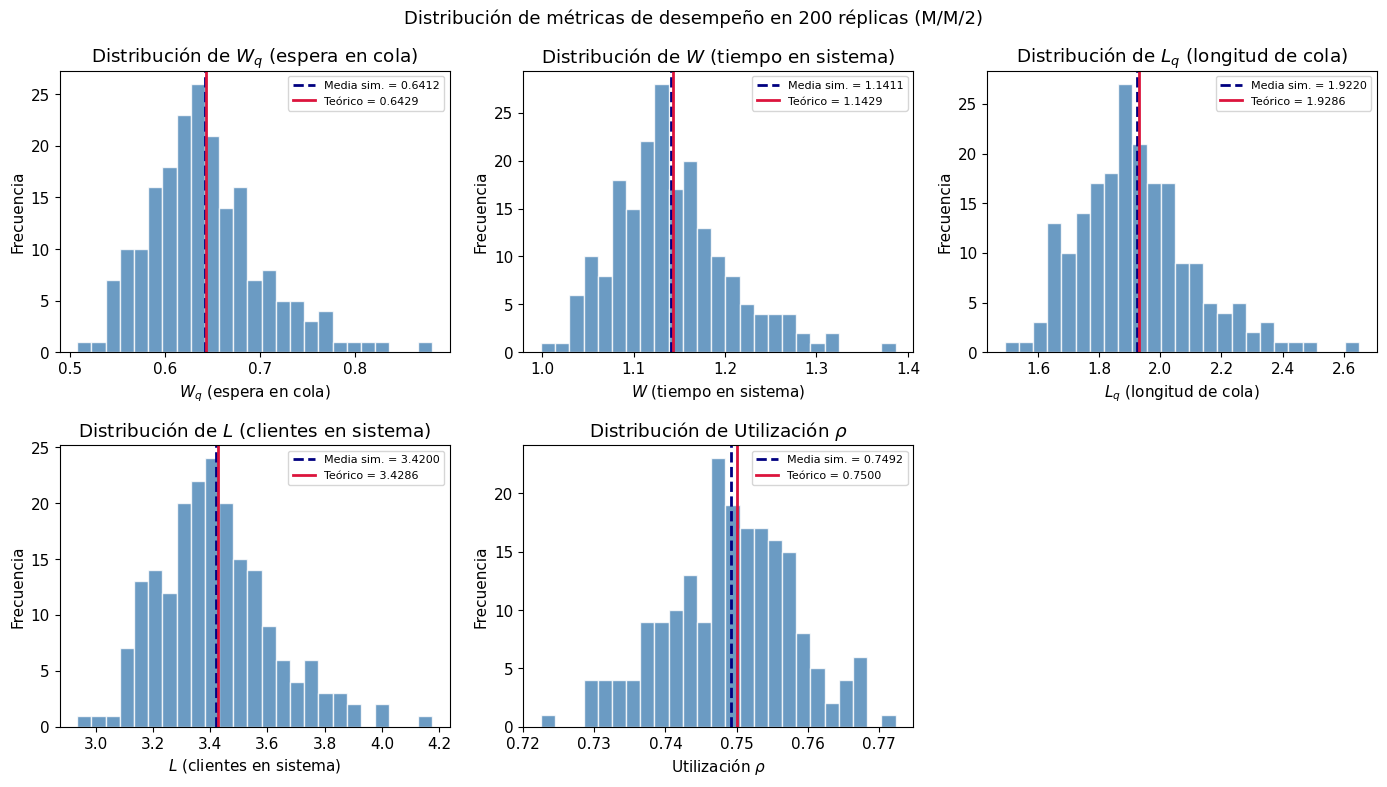

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

labels = {"Wq": "$W_q$ (espera en cola)", "W": "$W$ (tiempo en sistema)",
          "Lq": "$L_q$ (longitud de cola)", "L": "$L$ (clientes en sistema)",
          "utilizacion": "Utilización $\\rho$"}

for i, m in enumerate(metricas):
    ax = axes[i]
    ax.hist(df_rep[m], bins=25, edgecolor='white', alpha=0.8, color='steelblue')
    ax.axvline(df_rep[m].mean(), color='navy', linewidth=2, linestyle='--', label=f'Media sim. = {df_rep[m].mean():.4f}')
    ax.axvline(teoricos[m], color='crimson', linewidth=2, linestyle='-', label=f'Teórico = {teoricos[m]:.4f}')
    ax.set_xlabel(labels[m])
    ax.set_ylabel("Frecuencia")
    ax.set_title(f"Distribución de {labels[m]}")
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle(f"Distribución de métricas de desempeño en {R} réplicas (M/M/{C})", fontsize=13)
plt.tight_layout()
plt.show()

Los histogramas muestran la distribución empírica de cada métrica entre réplicas. Se espera que:

- La distribución sea aproximadamente normal (por el TCL aplicado a la media de cada réplica).
- La media simulada (línea azul) esté próxima al valor teórico (línea roja).
- La dispersión refleje la variabilidad natural del sistema bajo el horizonte $T$ elegido.

Desviaciones sistemáticas entre media simulada y valor teórico pueden indicar sesgo de inicialización, que se discutirá más adelante.

### Evolución de la media acumulada

Un análisis útil es observar cómo converge la media acumulada $\bar{Y}_r = \frac{1}{r}\sum_{j=1}^r Y_j$ a medida que se añaden réplicas. Esto ilustra la ley de los grandes números en acción.

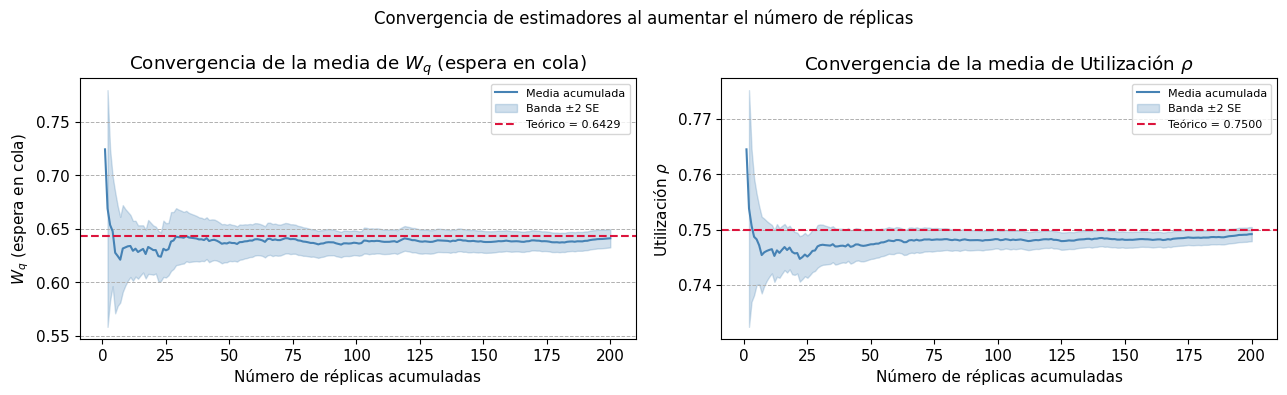

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, metrica, label in zip(
    axes,
    ["Wq", "utilizacion"],
    ["$W_q$ (espera en cola)", "Utilización $\\rho$"],
):
    media_acum = df_rep[metrica].expanding().mean()
    std_acum   = df_rep[metrica].expanding().std(ddof=1)
    n_acum     = np.arange(1, R + 1)
    
    # Se omite el primer punto porque std no está definida para n=1
    mask = n_acum >= 2
    se_band = std_acum / np.sqrt(n_acum)
    
    ax.plot(n_acum, media_acum, color='steelblue', label='Media acumulada')
    ax.fill_between(
        n_acum[mask],
        (media_acum - 2 * se_band)[mask],
        (media_acum + 2 * se_band)[mask],
        alpha=0.25, color='steelblue', label='Banda ±2 SE'
    )
    ax.axhline(teoricos[metrica], color='crimson', linewidth=1.5,
               linestyle='--', label=f'Teórico = {teoricos[metrica]:.4f}')
    ax.set_xlabel("Número de réplicas acumuladas")
    ax.set_ylabel(label)
    ax.set_title(f"Convergencia de la media de {label}")
    ax.legend(fontsize=8)
    ax.grid(axis='y', linestyle='--', linewidth=0.7)
    

plt.suptitle("Convergencia de estimadores al aumentar el número de réplicas", fontsize=12)
plt.tight_layout()
plt.show()

La gráfica muestra cómo la media acumulada oscila inicialmente (pocas réplicas $\Rightarrow$ alta incertidumbre) y luego se estabiliza cerca del valor teórico. La banda sombreada representa el error estándar de la media, que decrece a razón de $1/\sqrt{R}$.

## Construcción de intervalos de confianza

### Fundamento estadístico

Con $R$ réplicas independientes y la estadística $t$ de Student, un intervalo de confianza de nivel $1 - \alpha$ para $\theta$ es:

$$
\bar{Y} \pm t_{R-1,\, 1-\alpha/2} \cdot \frac{S}{\sqrt{R}}
$$

donde:
- $\bar{Y}$: media muestral de las $R$ réplicas,
- $S$: desviación estándar muestral entre réplicas,
- $t_{R-1,\, 1-\alpha/2}$: cuantil $1-\alpha/2$ de la distribución $t$ con $R-1$ grados de libertad,
- $S/\sqrt{R}$: error estándar de la media (SE).

La **semiancho** del intervalo es:

$$
h = t_{R-1,\, 1-\alpha/2} \cdot \frac{S}{\sqrt{R}}
$$

La interpretación frecuentista es: si se repitiera el experimento muchas veces (tomando $R$ réplicas cada vez y construyendo el IC), el $(1-\alpha)\times 100\%$ de esos intervalos contendría el verdadero valor $\theta$.

### Implementación del intervalo de confianza

In [9]:
def intervalo_confianza(datos, alpha=0.05):
    """
    Construye un intervalo de confianza t de Student al nivel (1-alpha)*100%.
    
    Parámetros
    ----------
    datos : array-like de observaciones (una por réplica)
    alpha : nivel de significancia (default 0.05 → IC al 95%)
    
    Retorna
    -------
    (media, li, ls, semiancho, se)
    """
    datos = np.asarray(datos)
    R  = len(datos)
    ybar = np.mean(datos)
    S  = np.std(datos, ddof=1)
    se = S / np.sqrt(R)
    t_crit = stats.t.ppf(1 - alpha / 2, df=R - 1)
    h = t_crit * se
    return ybar, ybar - h, ybar + h, h, se


# Construir ICs para todas las métricas
filas = []
for m in metricas:
    media, li, ls, h, se = intervalo_confianza(df_rep[m])
    tval = teoricos[m]
    dentro = li <= tval <= ls
    filas.append({
        "Métrica": m,
        "Media sim.": round(media, 5),
        "IC 95% inf.": round(li, 5),
        "IC 95% sup.": round(ls, 5),
        "Semiancho h": round(h, 5),
        "Error std. (SE)": round(se, 5),
        "Valor teórico": round(tval, 5),
        "¿Teórico en IC?": "✓" if dentro else "✗"
    })

pd.DataFrame(filas).set_index("Métrica")

,Media sim.,IC 95% inf.,IC 95% sup.,Semiancho h,Error std. (SE),Valor teórico,¿Teórico en IC?
Métrica,,,,,,,
Wq,0.64116,0.63275,0.64957,0.00841,0.00426,0.64286,✓
W,1.14106,1.13229,1.14982,0.00876,0.00444,1.14286,✓
Lq,1.92197,1.89575,1.94819,0.02622,0.01330,1.92857,✓
L,3.42000,3.39190,3.44810,0.02810,0.01425,3.42857,✓
utilizacion,0.74917,0.74791,0.75043,0.00126,0.00064,0.75000,✓


La columna **"¿Teórico en IC?"** verifica si el valor teórico cae dentro del intervalo de confianza simulado. Para un IC al 95% bien construido, se espera que esto ocurra en aproximadamente el 95% de los experimentos. Que el valor teórico esté dentro del IC respalda tanto la correcta implementación del modelo como la validez estadística del estimador.

### Visualización de los intervalos de confianza

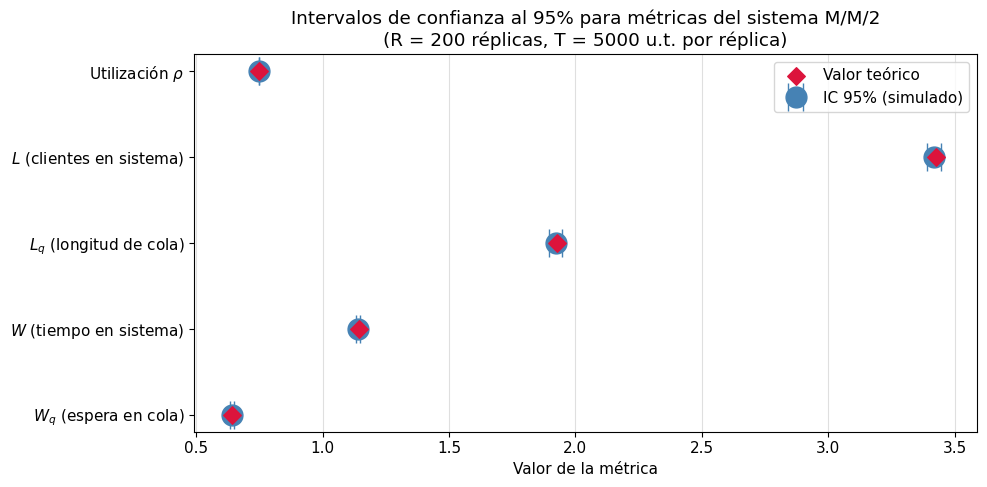

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

y_pos = np.arange(len(metricas))
medias = [intervalo_confianza(df_rep[m])[0] for m in metricas]
li_vals = [intervalo_confianza(df_rep[m])[1] for m in metricas]
ls_vals = [intervalo_confianza(df_rep[m])[2] for m in metricas]
teo_vals = [teoricos[m] for m in metricas]

errores_inf = [m - li for m, li in zip(medias, li_vals)]
errores_sup = [ls - m for m, ls in zip(medias, ls_vals)]

ax.errorbar(
    medias, y_pos,
    xerr=[errores_inf, errores_sup],
    fmt='o', color='steelblue', ecolor='steelblue',
    elinewidth=5, capsize=10, markersize=15, label='IC 95% (simulado)'
)
ax.scatter(teo_vals, y_pos, color='crimson', zorder=5, s=80, marker='D', label='Valor teórico')

ax.set_yticks(y_pos)
ax.set_yticklabels([labels[m] for m in metricas])
ax.set_xlabel("Valor de la métrica")
ax.set_title(f"Intervalos de confianza al 95% para métricas del sistema M/M/{C}\n(R = {R} réplicas, T = {T} u.t. por réplica)")
ax.legend()
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

El gráfico de barras de error muestra simultáneamente la media simulada, el intervalo de confianza al 95% y el valor teórico para cada métrica. El diamante rojo (valor teórico) debe quedar dentro de las barras de error en la mayoría de los casos.

## Eficiencia estadística: determinación del número de réplicas

### El problema de la precisión

Una pregunta central en cualquier experimento de simulación es: **¿cuántas réplicas son suficientes?**

La respuesta depende de tres elementos:
1. La **variabilidad** del sistema ($S$): mayor variabilidad requiere más réplicas.
2. La **precisión deseada**: cuánto error se está dispuesto a tolerar.
3. El **nivel de confianza** deseado ($1-\alpha$).

### Criterio de precisión absoluta

Se desea que el semiancho del IC no supere un valor absoluto $\epsilon$:

$$
h = t_{R-1,\, 1-\alpha/2} \cdot \frac{S}{\sqrt{R}} \leq \epsilon
$$

Despejando $R$:

$$
R \geq \left\lceil \left( \frac{t_{R-1,\, 1-\alpha/2} \cdot S}{\epsilon} \right)^2 \right\rceil
$$

Como $R$ aparece en ambos lados (a través del cuantil $t$), se resuelve iterativamente partiendo de un $R_0$ piloto.

### Criterio de precisión relativa

Alternativamente, se puede pedir un error relativo al $\gamma\%$ de la media:

$$
\epsilon_r = \gamma \cdot \bar{Y} \quad \Rightarrow \quad R \geq \left\lceil \left( \frac{t_{R-1,\, 1-\alpha/2} \cdot S}{\gamma \cdot \bar{Y}} \right)^2 \right\rceil
$$

In [11]:
def replicas_necesarias(datos_piloto, epsilon=None, gamma=None, alpha=0.05, max_iter=50):
    datos = np.asarray(datos_piloto)
    S = np.std(datos, ddof=1)
    ybar = np.mean(datos)

    if epsilon is None and gamma is not None:
        epsilon = gamma * abs(ybar)
    elif epsilon is None:
        raise ValueError("Debe especificar epsilon o gamma.")

    # Arrancar desde estimación inicial con normal estándar (z), sin asumir R
    z = stats.norm.ppf(1 - alpha / 2)
    R_est = math.ceil((z * S / epsilon) ** 2)
    R_est = max(R_est, 2)  # mínimo 2 para que df >= 1

    # Iterar refinando con t de Student hasta convergencia
    for _ in range(max_iter):
        t_crit = stats.t.ppf(1 - alpha / 2, df=R_est - 1)
        R_nuevo = math.ceil((t_crit * S / epsilon) ** 2)
        if R_nuevo <= R_est:
            break
        R_est = R_nuevo

    t_final = stats.t.ppf(1 - alpha / 2, df=R_est - 1)
    h_final = t_final * S / np.sqrt(R_est)
    return R_est, h_final, epsilon


# Análisis de réplicas necesarias para distintos niveles de precisión
print("Métrica: Wq (tiempo de espera en cola)")
print(f"Media estimada: {df_rep['Wq'].mean():.4f}")
print(f"Desv. estándar entre réplicas: {df_rep['Wq'].std(ddof=1):.4f}")
print()

gammas = [0.10, 0.05, 0.02, 0.01]
filas = []
for g in gammas:
    R_nec, h, eps = replicas_necesarias(df_rep["Wq"], gamma=g)
    filas.append({
        "Precisión relativa (γ)": f"{g*100:.0f}%",
        "ε absoluto": round(eps, 5),
        "R necesario": R_nec,
        "Semiancho IC resultante": round(h, 5)
    })

pd.DataFrame(filas)

Métrica: Wq (tiempo de espera en cola)
Media estimada: 0.6412
Desv. estándar entre réplicas: 0.0603



,Precisión relativa (γ),ε absoluto,R necesario,Semiancho IC resultante
0,10%,0.06412,9,0.04635
1,5%,0.03206,17,0.03100
2,2%,0.01282,88,0.01278
3,1%,0.00641,343,0.00640


La tabla muestra la relación entre la precisión deseada y el número de réplicas necesario. Note que:

- Pasar del 2% al 1% de precisión (reducir $\epsilon$ a la mitad) requiere aproximadamente **cuatro veces más réplicas** (de 88 a 343), lo que confirma la relación $R \propto 1/\epsilon^2$.
- El salto de 10% a 1% implica pasar de 9 a 343 réplicas, es decir, **38 veces más**, no solo un orden de magnitud.
- La relación cuadrática se verifica exactamente cuando se comparan intervalos de precisión que se dividen por un factor constante (2%→1%). Cuando los saltos de $\gamma$ no son uniformes (5%→2%), el multiplicador observado difiere.


Esto ilustra el **costo cuadrático de la precisión**: cada vez que se quiere el doble de exactitud, el costo computacional se cuadruplica.

> **Nota:** La relación $R \propto 1/\epsilon^2$ es una aproximación asintótica. Para el par 10%→5% se observan 9→17 réplicas (~2x en lugar del 4x teórico) porque con tan pocas réplicas el cuantil $t_{R-1}$ es notablemente mayor que $z$: por ejemplo $t_{8,\, 0.975} = 2.306$ frente a $z_{0.975} = 1.96$, una diferencia del 18% que eleva el resultado. La relación cuadrática solo se cumple bien cuando $R$ es suficientemente grande para que $t_{R-1} \approx z$, lo que ocurre aproximadamente a partir de 30 réplicas. Por eso el par 2%→1% (88→343, ~4x) sí confirma la teoría y el par 10%→5% no.

### Método secuencial: agregar réplicas hasta alcanzar precisión

Precisión alcanzada con R = 7 réplicas
  Media Wq = 0.66387, IC 95%: [0.63493, 0.69281]
  Semiancho relativo = 4.36% (objetivo: 5%)


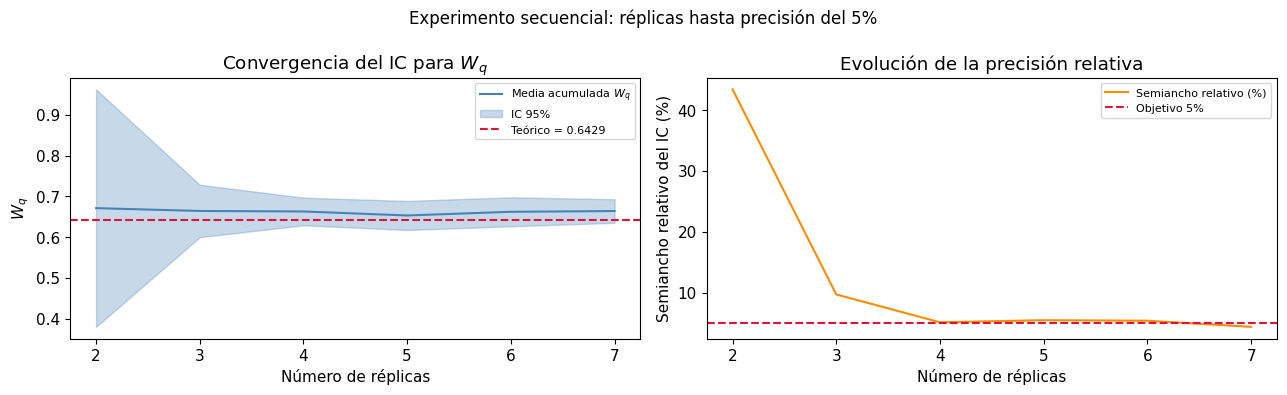

In [12]:
def experimento_secuencial(lam, mu, c, T, gamma_objetivo=0.05, alpha=0.05,
                           R_piloto=10, R_max=500, seed_base=2000):
    """
    Ejecuta réplicas secuencialmente hasta que el IC para Wq alcanza
    una precisión relativa gamma_objetivo.
    """
    resultados = []
    historia = []  # guarda (R, media, li, ls, h_relativo)
    
    # Fase piloto
    for j in range(R_piloto):
        res = simular_mmc(lam=lam, mu=mu, c=c, T=T, seed=seed_base + j)
        resultados.append(res["Wq"])
    
    # Fase secuencial
    j = R_piloto
    while j < R_max:
        datos = np.array(resultados)
        media, li, ls, h, _ = intervalo_confianza(datos, alpha=alpha)
        h_rel = h / abs(media) if media != 0 else np.inf
        historia.append({"R": j, "media": media, "li": li, "ls": ls, "h_rel": h_rel})
        
        if h_rel <= gamma_objetivo:
            print(f"Precisión alcanzada con R = {j} réplicas")
            print(f"  Media Wq = {media:.5f}, IC 95%: [{li:.5f}, {ls:.5f}]")
            print(f"  Semiancho relativo = {h_rel*100:.2f}% (objetivo: {gamma_objetivo*100:.0f}%)")
            break
        
        res = simular_mmc(lam=lam, mu=mu, c=c, T=T, seed=seed_base + j)
        resultados.append(res["Wq"])
        j += 1
    else:
        print(f"Máximo de {R_max} réplicas alcanzado sin cumplir la precisión.")
    
    return pd.DataFrame(historia)


hist = experimento_secuencial(LAM, MU, C, T, gamma_objetivo=0.05, R_piloto=2)

# Visualización de la convergencia secuencial
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(hist["R"], hist["media"], color='steelblue', label='Media acumulada $W_q$')
ax.fill_between(hist["R"], hist["li"], hist["ls"], alpha=0.3, color='steelblue', label='IC 95%')
ax.axhline(teo["Wq"], color='crimson', linestyle='--', linewidth=1.5, label=f'Teórico = {teo["Wq"]:.4f}')
ax.set_xlabel("Número de réplicas")
ax.set_ylabel("$W_q$")
ax.set_title("Convergencia del IC para $W_q$")
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(hist["R"], hist["h_rel"] * 100, color='darkorange', label='Semiancho relativo (%)')
ax.axhline(5, color='crimson', linestyle='--', linewidth=1.5, label='Objetivo 5%')
ax.set_xlabel("Número de réplicas")
ax.set_ylabel("Semiancho relativo del IC (%)")
ax.set_title("Evolución de la precisión relativa")
ax.legend(fontsize=8)

plt.suptitle("Experimento secuencial: réplicas hasta precisión del 5%", fontsize=12)
plt.tight_layout()
plt.show()

El experimento secuencial ilustra el procedimiento práctico en simulación: en lugar de especificar $R$ a priori, se agregan réplicas hasta que el IC satisface el criterio de precisión deseado. La gráfica de la derecha muestra cómo el semiancho relativo decrece con cada réplica adicional hasta cruzar el umbral objetivo.

## Impacto del horizonte de simulación en la varianza entre réplicas

La varianza entre réplicas depende no solo del sistema sino también del horizonte $T$. Aumentar $T$ reduce la varianza de cada estimador $Y_j$, lo que a su vez permite construir ICs más estrechos con el mismo número de réplicas.

Existe por tanto un balance: ¿es preferible pocas réplicas largas o muchas réplicas cortas?

Para un costo computacional total fijo $C_{total} = R \times T$, se puede analizar la combinación óptima.

In [13]:
# Experimento: distintas combinaciones (R, T) con costo total fijo
COSTO_TOTAL = 50_000  # R * T = constante

combinaciones = [
    (10,  5_000),
    (20,  2_500),
    (50,  1_000),
    (100,   500),
    (250,   200),
]

filas_rt = []
for R_comb, T_comb in combinaciones:
    df_comb = ejecutar_replicas(R_comb, T=T_comb, seed_base=5000)
    media, li, ls, h, se = intervalo_confianza(df_comb["Wq"])
    filas_rt.append({
        "R": R_comb,
        "T": T_comb,
        "R × T": R_comb * T_comb,
        "Media Wq": round(media, 5),
        "S entre réplicas": round(df_comb['Wq'].std(ddof=1), 5),
        "SE": round(se, 5),
        "Semiancho IC 95%": round(h, 5),
        "IC inf.": round(li, 5),
        "IC sup.": round(ls, 5)
    })

df_rt = pd.DataFrame(filas_rt)
df_rt

,R,T,R × T,Media Wq,S entre réplicas,SE,Semiancho IC 95%,IC inf.,IC sup.
0,10,5000,50000,0.64464,0.04656,0.01472,0.03331,0.61134,0.67795
1,20,2500,50000,0.65614,0.06957,0.01556,0.03256,0.62358,0.68870
2,50,1000,50000,0.66591,0.13709,0.01939,0.03896,0.62695,0.70487
3,100,500,50000,0.66516,0.18196,0.01820,0.03610,0.62905,0.70126
4,250,200,50000,0.62723,0.27293,0.01726,0.03400,0.59323,0.66123


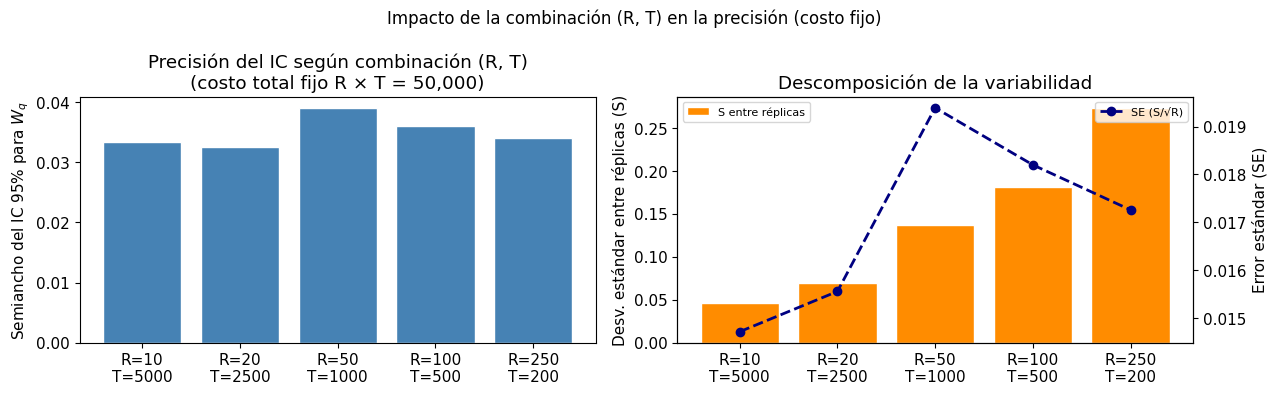

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
x = range(len(combinaciones))
xlabs = [f"R={r}\nT={t}" for r, t in combinaciones]
ax.bar(x, df_rt["Semiancho IC 95%"], color='steelblue', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(xlabs)
ax.set_ylabel("Semiancho del IC 95% para $W_q$")
ax.set_title("Precisión del IC según combinación (R, T)\n(costo total fijo R × T = 50,000)")

ax = axes[1]
ax.bar(x, df_rt["S entre réplicas"], color='darkorange', edgecolor='white', label='S entre réplicas')
ax2 = ax.twinx()
ax2.plot(x, df_rt["SE"], 'o--', color='navy', linewidth=2, label='SE (S/√R)')
ax.set_xticks(x)
ax.set_xticklabels(xlabs)
ax.set_ylabel("Desv. estándar entre réplicas (S)")
ax2.set_ylabel("Error estándar (SE)")
ax.set_title("Descomposición de la variabilidad")
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.suptitle("Impacto de la combinación (R, T) en la precisión (costo fijo)", fontsize=12)
plt.tight_layout()
plt.show()

**Lectura de los resultados:**

- $S$ (desviación entre réplicas) crece consistentemente al reducir $T$: de 0.047 con T=5000 hasta 0.273 con T=200. Réplicas más cortas son individualmente más ruidosas porque cada corrida captura menos del comportamiento estacionario del sistema.
- El SE ($S/\sqrt{R}$) no decrece monótonamente: sube de 0.0147 (R=10) hasta 0.0194 (R=50) y luego baja hasta 0.0173 (R=250). Esto ocurre porque en la zona intermedia $S$ crece más rápido de lo que $\sqrt{R}$ lo compensa.
- El semiancho del IC refleja ese mismo patrón no monótono: el **peor resultado es R=50, T=1000** (h=0.039) y el **óptimo es R=20, T=2500** (h=0.033), que supera incluso a R=10, T=5000 (h=0.033) por una pequeña diferencia.

Bajo este costo fijo de $R \times T = 50{,}000$, la combinación **R=20, T=2500** ofrece el mejor balance: réplicas suficientemente largas para estimar $W_q$ con baja varianza individual, y suficientes réplicas para que el SE sea competitivo. El resultado ilustra que ni el extremo de pocas réplicas muy largas ni el de muchas réplicas muy cortas es óptimo — existe un punto intermedio que minimiza el semiancho del IC.

## Análisis comparativo: M/M/1 vs. M/M/2 vs. M/M/3

Se comparan tres configuraciones del sistema bajo la misma carga total $\lambda = 3$, variando el número de servidores. Este análisis ilustra cómo las decisiones de diseño afectan tanto el desempeño como la variabilidad de las estimaciones.

In [15]:
configuraciones = [
    {"lam": 1.5, "mu": 2.0, "c": 1, "label": "M/M/1 (ρ=0.75)"},
    {"lam": 3.0, "mu": 2.0, "c": 2, "label": "M/M/2 (ρ=0.75)"},
    {"lam": 4.5, "mu": 2.0, "c": 3, "label": "M/M/3 (ρ=0.75)"},
]

R_comp = 100
T_comp = 3_000

resultados_comp = {}
for conf in configuraciones:
    df_c = ejecutar_replicas(R_comp, lam=conf["lam"], mu=conf["mu"], c=conf["c"],
                              T=T_comp, seed_base=7000)
    teo_c = teoria_mmc(conf["lam"], conf["mu"], conf["c"])
    media, li, ls, h, _ = intervalo_confianza(df_c["Wq"])
    resultados_comp[conf["label"]] = {
        "df": df_c,
        "media": media, "li": li, "ls": ls, "h": h,
        "S": df_c["Wq"].std(ddof=1),
        "CV": df_c["Wq"].std(ddof=1) / media * 100,
        "teo_Wq": teo_c["Wq"]
    }

# Tabla resumen
filas_comp = []
for label, res in resultados_comp.items():
    filas_comp.append({
        "Configuración": label,
        "Media W_q sim.": round(res["media"], 5),
        "W_q teórico": round(res["teo_Wq"], 5),
        "IC 95% inf.": round(res["li"], 5),
        "IC 95% sup.": round(res["ls"], 5),
        "Semiancho h": round(res["h"], 5),
        "CV entre réplicas (%)": round(res["CV"], 2)
    })

pd.DataFrame(filas_comp).set_index("Configuración")

,Media W_q sim.,W_q teórico,IC 95% inf.,IC 95% sup.,Semiancho h,CV entre réplicas (%)
Configuración,,,,,,
M/M/1 (ρ=0.75),1.48878,1.50000,1.45166,1.52589,0.03711,12.56
M/M/2 (ρ=0.75),0.63787,0.64286,0.62323,0.65250,0.01463,11.56
M/M/3 (ρ=0.75),0.37744,0.37850,0.37066,0.38423,0.00679,9.06


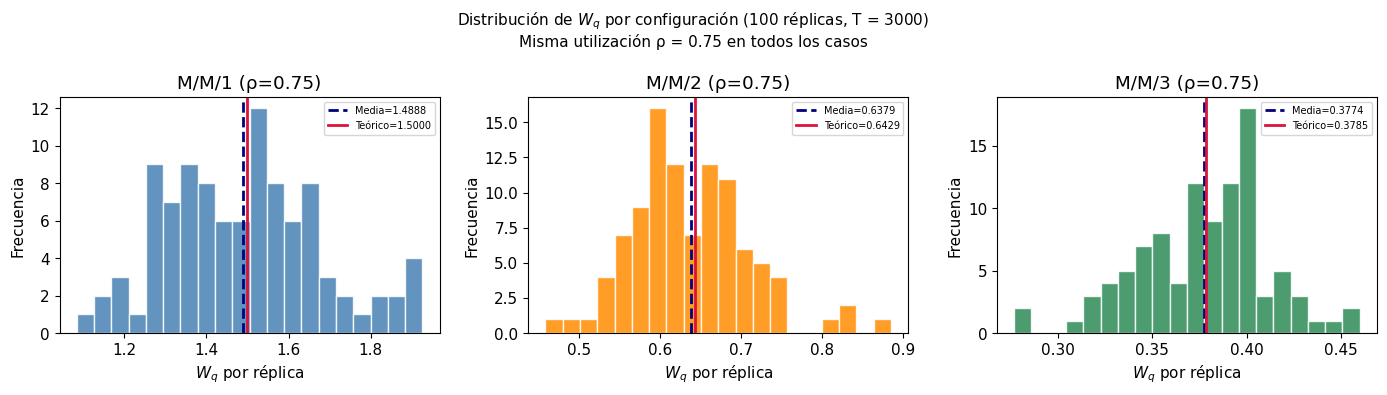

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

colores = ['steelblue', 'darkorange', 'seagreen']
for ax, (label, res), color in zip(axes, resultados_comp.items(), colores):
    ax.hist(res["df"]["Wq"], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(res["media"], color='navy', linewidth=2, linestyle='--',
               label=f'Media={res["media"]:.4f}')
    ax.axvline(res["teo_Wq"], color='crimson', linewidth=2,
               label=f'Teórico={res["teo_Wq"]:.4f}')
    ax.set_title(label)
    ax.set_xlabel("$W_q$ por réplica")
    ax.set_ylabel("Frecuencia")
    ax.legend(fontsize=7)

plt.suptitle(f"Distribución de $W_q$ por configuración ({R_comp} réplicas, T = {T_comp})\n"
             "Misma utilización ρ = 0.75 en todos los casos", fontsize=11)
plt.tight_layout()
plt.show()

Bajo la misma utilización $\rho = 0.75$, los sistemas M/M/c con más servidores presentan:

- Menor tiempo medio de espera en cola absoluto (economías de escala en el servicio paralelo).
- Diferente dispersión entre réplicas, lo que afecta el número de réplicas necesario para estimarlos con igual precisión.

Esto tiene implicaciones directas para el diseño de experimentos de simulación: la **eficiencia estadística depende del sistema modelado**, no solo del procedimiento estadístico.

## Corrida larga, período de warm-up y batch means

Hasta este punto, la estrategia para estimar métricas de desempeño ha sido **réplicas independientes**: ejecutar $R$ corridas, cada una de horizonte $T$, partiendo del mismo estado inicial (sistema vacío) y con semillas distintas. Esta es la estrategia más limpia desde el punto de vista estadístico porque las réplicas son i.i.d. y el TCL aplica directamente.

Sin embargo, en muchos sistemas reales esta estrategia tiene dos limitaciones importantes:

1. **El estado inicial introduce sesgo.** Si interesa el comportamiento del sistema **en estado estacionario**, comenzar siempre desde el sistema vacío contamina las primeras observaciones de cada réplica. Las métricas calculadas durante esa fase transitoria no son representativas del régimen estable.

2. **Cada réplica desperdicia tiempo en converger.** Si $R = 30$ réplicas de longitud $T$ se "calientan" durante un tiempo $T_w$ cada una, el costo computacional total tiene una componente de $30 \, T_w$ minutos simulados que no aportan información del régimen estacionario.

Una alternativa es ejecutar **una sola réplica muy larga**, descartar el período inicial transitorio (warm-up), y dividir el resto en lotes (batches) que se traten como si fueran réplicas independientes. Este método se conoce como **batch means**, y es el enfoque estándar cuando el sistema es complejo, no tiene un punto de "regreso al vacío" obvio, o el estado inicial es difícil de muestrear correctamente.

### Comparación de los dos enfoques

| Característica | Réplicas independientes | Batch means |
|---|---|---|
| Número de corridas | $R$ corridas independientes | 1 corrida muy larga |
| Estado inicial | Cada réplica empieza vacía | Solo se descarta una vez (warm-up) |
| Lotes/réplicas | Naturalmente independientes | Casi independientes (deben validarse) |
| Costo del transitorio | $R \cdot T_w$ tiempo simulado | $T_w$ tiempo simulado |
| Aplicabilidad | Sistemas que regresan al estado inicial | Sistemas en régimen estacionario |
| Validación adicional | Ninguna | Verificar autocorrelación entre lotes |

A continuación se desarrolla el flujo completo: (i) ejecutar una corrida larga, (ii) identificar visualmente el warm-up, (iii) aplicar batch means, (iv) validar la independencia de los lotes y (v) comparar con la estrategia de réplicas independientes.


### Simulador extendido con trayectoria $N(t)$

Para identificar el warm-up necesitamos observar **cómo evoluciona el sistema en el tiempo**, no solo los promedios al final. Por eso modificamos el simulador M/M/c para que también devuelva la trayectoria del número de clientes en el sistema, $N(t)$, registrando cada cambio de estado (llegada o salida).

Esta versión registra la pareja $(t, N(t))$ cada vez que un cliente entra o sale del sistema. La estructura del simulador es idéntica a la anterior; solo se agrega el registro de la trayectoria.


In [17]:
def simular_mmc_trayectoria(lam=3.0, mu=2.0, c=2, T=5_000, seed=42):
    """
    Simula un M/M/c y devuelve también la trayectoria N(t) = clientes en el sistema.
    
    Parámetros
    ----------
    lam, mu, c, T, seed : igual que simular_mmc
    
    Retorna
    -------
    dict con métricas + trayectoria como dos arrays:
        - 'ts' : instantes de cambio de estado
        - 'ns' : N(t) en cada instante
    """
    rho = lam / (c * mu)
    if rho >= 1:
        print(f"ADVERTENCIA: ρ = {rho:.3f} >= 1. Sistema inestable.")
    
    random.seed(seed)
    env = simpy.Environment()
    servidores = simpy.Resource(env, capacity=c)
    
    mon = {
        "arrivals": 0, "departures": 0,
        "busy_time": 0.0,
        "waits": [], "system_times": [],
        "ts": [0.0], "ns": [0]   # Se agregan 2 listas que monitorean la trayectoria, es decir, N(t) a lo largo del tiempo
    }
    #----------------------------------------------------------
    # Funcion nueva para registrar la trayectoria N(t) en cada cambio de estado
    #-----------------------------------------------------------
    def registrar_estado():
        """Agrega un punto a la trayectoria con el estado actual."""
        n_actual = servidores.count + len(servidores.queue)
        mon["ts"].append(env.now)
        mon["ns"].append(n_actual)
    
    def cliente(env, cid):
        t_llegada = env.now
        with servidores.request() as req:
            registrar_estado()      # tras el request: el cliente ya cuenta en queue/count
            yield req
            t_inicio = env.now
            espera = t_inicio - t_llegada
            t_serv = random.expovariate(mu)
            mon["busy_time"] += t_serv
            yield env.timeout(t_serv)
        registrar_estado()          # tras el release: el cliente ya salió
        mon["waits"].append(espera)
        mon["system_times"].append(env.now - t_llegada)
        mon["departures"] += 1
    
    def generador(env):
        i = 0
        while True:
            yield env.timeout(random.expovariate(lam))
            i += 1
            mon["arrivals"] += 1
            env.process(cliente(env, i))
    
    env.process(generador(env))
    env.run(until=T)
    
    n = mon["departures"]
    Wq = statistics.mean(mon["waits"]) if mon["waits"] else 0.0
    W  = statistics.mean(mon["system_times"]) if mon["system_times"] else 0.0
    util = mon["busy_time"] / (c * T)
    lambda_ef = n / T
    
    return {
        "n_clientes": n,
        "Wq": Wq, "W": W,
        "Lq": lambda_ef * Wq, "L": lambda_ef * W,
        "utilizacion": util,
        "ts": np.asarray(mon["ts"]),
        "ns": np.asarray(mon["ns"]),
    }


### Ejecución de una corrida larga

Se ejecuta una sola réplica con un horizonte $T = 50{,}000$ unidades de tiempo (10 veces más larga que las réplicas anteriores). Este horizonte debe ser suficiente para que el sistema se estabilice y para que los lotes que se construyan después tengan tamaño razonable.

La condición práctica es que $T$ sea mucho mayor que el tiempo característico de relajación del sistema. Para una M/M/c con utilización $\rho$, este tiempo es del orden de $\frac{1}{(1-\rho) \mu}$, así que para $\rho = 0.75$, $\mu = 2$, da aproximadamente 2 unidades de tiempo. Un horizonte de 50,000 contiene del orden de 25,000 ciclos de relajación: suficiente.


In [18]:
T_largo = 50_000
corrida = simular_mmc_trayectoria(lam=LAM, mu=MU, c=C, T=T_largo, seed=42)

ts = corrida["ts"]
ns = corrida["ns"]

print(f"Corrida larga ejecutada")
print(f"  Horizonte T   : {T_largo:,} unidades de tiempo")
print(f"  Clientes      : {corrida['n_clientes']:,}")
print(f"  Cambios de estado registrados : {len(ts):,}")
print(f"  N̄(t) global   : {np.mean(ns):.4f}  (incluye el transitorio)")
print(f"  L teórico     : {teoricos['L']:.4f}")


Corrida larga ejecutada
  Horizonte T   : 50,000 unidades de tiempo
  Clientes      : 149,739
  Cambios de estado registrados : 299,486
  N̄(t) global   : 3.9595  (incluye el transitorio)
  L teórico     : 3.4286


La trayectoria contiene cientos de miles de cambios de estado: cada llegada o salida produce una transición. Si simplemente se promedia $N(t)$ sobre toda la corrida, el resultado tiene un sesgo a la baja porque al inicio el sistema está vacío durante un período no despreciable.

Para visualizar este efecto se grafica la trayectoria junto con su **media móvil**, calculada sobre una grilla regular en el tiempo.


### Identificación visual del período de warm-up

La trayectoria $N(t)$ es muy ruidosa, por lo que conviene **suavizarla** para ver la tendencia. Se procede así:

1. Construir una grilla regular de tiempos $t_0, t_1, \ldots, t_M$ entre $0$ y $T$ para representar el comportamiento.
2. Interpolar la trayectoria (el comportamiento) de $N(t)$ a esa grilla para obtener valores estimados en esos puntos.
3. Calcular una media móvil de ventana fija sobre la versión interpolada para suavizar los puntos.

El warm-up se elige como el tiempo a partir del cual la media móvil **se estabiliza alrededor de un valor constante**. Es una decisión basada en inspección visual; lo importante es ser consistente con el método y reportar el valor elegido.


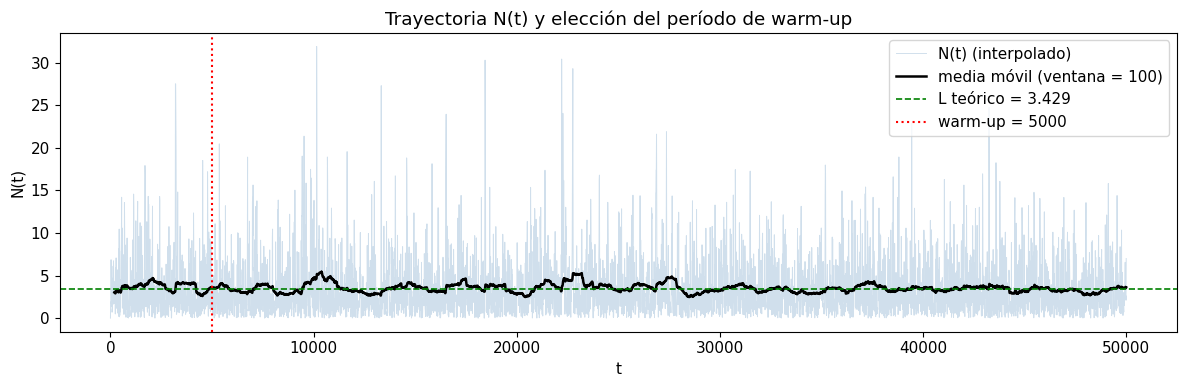

In [19]:
# Interpolación a una grilla regular y media móvil
M = 5000 #Numero de puntos en la grilla. A mayor valor, más valores de N(t) se muestran, pero también más ruido. 
         # Variar este parámetro para ver cómo afecta la visualización. Se recomienda probar con valores entre 2000 y 10000, dependiendo del contexto.
grid = np.linspace(0, T_largo, M + 1)  # grilla regular de tiempo para evaluar N(t)
n_grid = np.interp(grid, ts, ns) # interpolación lineal de N(t) en la grilla regular. para obtener valores de N(t) en puntos regulares, lo que facilita la visualización y el análisis posterior.

ventana = 100    # tamaño de ventana de la media móvil (en puntos de grilla)
                 # Variar este parámetro para ver cómo afecta la suavización. Se recomienda probar con valores entre 50 y 200, dependiendo del contexto.
mavg = pd.Series(n_grid).rolling(ventana, min_periods=20).mean() # media móvil para suavizar la trayectoria. El parámetro min_periods=20 asegura que se calcule la media móvil solo cuando hay al menos 20 puntos disponibles, lo que evita valores NaN al inicio de la serie.

# Elección del warm-up por inspección visual
T_warmup = 5_000.0 # Se puede ajustar este valor según la gráfica. 
                   # Tomamos un valor conservador que claramente supera el período de transitorio inicial, pero no tan largo como para desperdiciar demasiados datos útiles.

#Gráfica de la trayectoria N(t) con la media móvil, valor teórico y el período de warm-up indicado
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(grid, n_grid, alpha=0.25, linewidth=0.7, label="N(t) (interpolado)", color="steelblue")
ax.plot(grid, mavg, color="black", linewidth=1.8, label=f"media móvil (ventana = {ventana})")
ax.axhline(teoricos['L'], color="green", linestyle="--", linewidth=1.2, label=f"L teórico = {teoricos['L']:.3f}")
ax.axvline(T_warmup, color="red", linestyle=":", linewidth=1.5, label=f"warm-up = {T_warmup:.0f}")
ax.set_xlabel("t")
ax.set_ylabel("N(t)")
ax.set_title("Trayectoria N(t) y elección del período de warm-up")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


La gráfica muestra que durante los primeros instantes la media móvil crece rápidamente desde 0 (estado inicial vacío) hacia el valor estacionario. Después de un tiempo deja de presentar tendencia y oscila alrededor de un valor estable, cercano al $L$ teórico (línea verde discontinua).

El warm-up elegido en este caso es $T_w = 5{,}000$. Esta elección es **conservadora**: el sistema parece haberse estabilizado bastante antes, pero descartar un período más largo no perjudica significativamente y reduce el riesgo de incluir observaciones aún sesgadas.

Existen métodos automáticos para elegir el warm-up (por ejemplo, el método de Welch, MSER, o pruebas de tendencia en lotes), pero la inspección visual con media móvil es robusta, sencilla y suficiente para la mayoría de aplicaciones.


### Método de batch means

Una vez descartado el warm-up, el intervalo $[T_w, T]$ contiene observaciones del sistema en régimen estacionario. La idea de batch means es:

1. Dividir $[T_w, T]$ en $B$ lotes igualmente espaciados.
2. Calcular el **promedio temporal** de $N(t)$ dentro de cada lote.
3. Tratar esos $B$ promedios como si fueran $B$ réplicas independientes.

Si los lotes son suficientemente largos, los promedios son aproximadamente i.i.d., y se puede aplicar la teoría del intervalo de confianza $t$ de Student tal como se hizo con réplicas independientes.

Para una métrica basada en $N(t)$, el promedio del lote $b$ que cubre el intervalo $[t_b, t_{b+1}]$ es:

$$
\bar N_b = \frac{1}{t_{b+1} - t_b} \int_{t_b}^{t_{b+1}} N(t) \, dt
$$

Como $N(t)$ es una función escalonada, esta integral se calcula exactamente mediante una **suma de áreas de rectángulos**: para cada par consecutivo $(t_i, N_i), (t_{i+1}, N_{i+1})$ dentro del lote, la contribución al área es $N_i \cdot (t_{i+1} - t_i)$.

A continuación se implementa la función y se aplica.


In [20]:
def batch_means(ts, ns, t0, t1, B=30):
    """
    Aplica batch means sobre una trayectoria N(t).
    
    Parámetros
    ----------
    ts : array de instantes de cambio de estado
    ns : array de valores de N(t) en cada instante
    t0, t1 : intervalo a considerar (típicamente t0 = warm-up, t1 = T)
    B  : número de lotes
    
    Retorna
    -------
    array con los B promedios temporales (uno por lote)
    """
    bordes = np.linspace(t0, t1, B + 1) # bordes de los lotes: B intervalos [a, c]
    medias = np.full(B, np.nan)
    
    for b in range(B):
        a, c = bordes[b], bordes[b + 1] # intervalo del lote b definido como [a, c]
        # Puntos de la trayectoria que caen dentro del lote
        mask = (ts >= a) & (ts <= c) # Crea un array "filtro" booleano. Busca todos los índices donde el tiempo (ts) está entre los límites a y c.
        tb, vb = ts[mask], ns[mask] #  Aplica el filtro para extraer solo los datos relevantes
        if len(tb) < 2: # No hay suficientes datos para calcular el promedi, se deja NaN
            continue
        # Promedio temporal: integral por trapecio escalonado / largo del lote
        medias[b] = np.sum(vb[:-1] * np.diff(tb)) / (tb[-1] - tb[0]) #vb[:-1] * -> Multiplica cada valor de N(t) por la duración del intervalo de tiempo siguiente, para obtener el área bajo la curva escalonada.
                                                                     #np.diff(tb) -> Calcula la duración de cada pequeño intervalo de tiempo
                                                                     # / (tb[-1] - tb[0]) -> Divide la suma total por el tiempo transcurrido total para obtener el valor promedio.
                                                                     #np.sum(...) -> Suma todas esas áreas (integración numérica)
    
    return medias


# Aplicación
B = 30
medias_lotes = batch_means(ts, ns, t0=T_warmup, t1=T_largo, B=B)
media_bm, li_bm, ls_bm, h_bm, se_bm = intervalo_confianza(medias_lotes)

print(f"Batch means con B = {B} lotes")
print(f"  Tamaño de lote      : {(T_largo - T_warmup)/B:.0f} unidades de tiempo")
print(f"  Estimación de L     : {media_bm:.4f}")
print(f"  IC 95%              : [{li_bm:.4f}, {ls_bm:.4f}]")
print(f"  Semiancho h         : {h_bm:.4f}")
print(f"  Valor teórico       : {teoricos['L']:.4f}")
print(f"  ¿Teórico en IC?     : {'✓' if li_bm <= teoricos['L'] <= ls_bm else '✗'}")


Batch means con B = 30 lotes
  Tamaño de lote      : 1500 unidades de tiempo
  Estimación de L     : 3.4476
  IC 95%              : [3.2985, 3.5967]
  Semiancho h         : 0.1491
  Valor teórico       : 3.4286
  ¿Teórico en IC?     : ✓


### Validación: autocorrelación entre lotes

El supuesto crítico de batch means es que los promedios de los lotes son **aproximadamente independientes**. Si los lotes son demasiado cortos, observaciones cercanas al final de un lote pueden estar correlacionadas con las del inicio del siguiente, violando el supuesto y subestimando la varianza del estimador.

Una forma sencilla de validar esto es calcular la **autocorrelación de orden 1** (lag-1) de la secuencia $\bar N_1, \bar N_2, \ldots, \bar N_B$:

$$
r_1 = \frac{\sum_{b=1}^{B-1} (\bar N_b - \bar{\bar N})(\bar N_{b+1} - \bar{\bar N})}{\sum_{b=1}^{B} (\bar N_b - \bar{\bar N})^2}
$$

**Regla práctica:** $|r_1| < 0.3$ se considera aceptable; $|r_1| < 0.1$ es muy bueno. Si $|r_1|$ es alto, hay dos opciones:

1. Aumentar el tamaño de los lotes (es decir, reducir $B$ manteniendo $T$ fijo, o aumentar $T$ manteniendo $B$ fijo).
2. Aumentar el horizonte total $T$ y rehacer.


Autocorrelación lag-1 entre lotes : r₁ = -0.0777
  → Muy buena: lotes prácticamente independientes


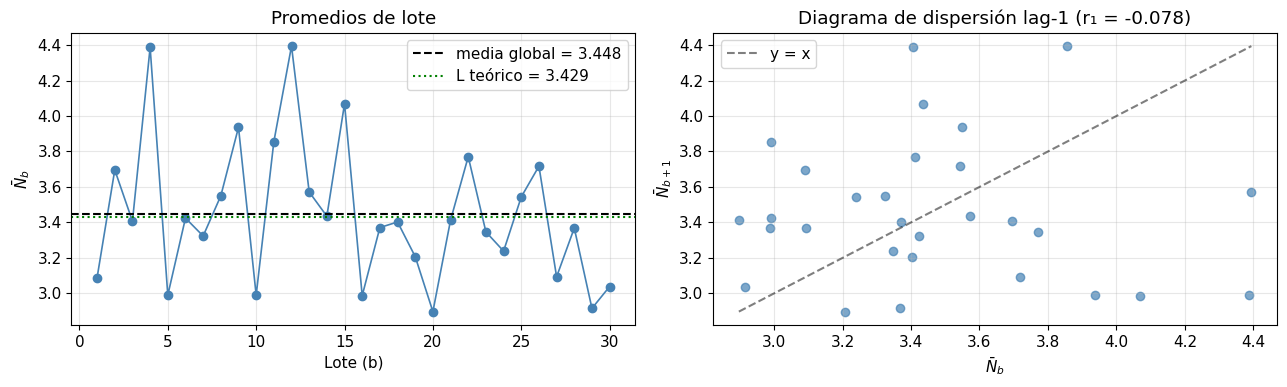

In [21]:
# Autocorrelación lag-1 de las medias de lote
medias_validas = medias_lotes[~np.isnan(medias_lotes)] # El símbolo ~ es un operador "bitwise NOT" (negación bit a bit).
                                                       # Se usa en lugar de 'not' porque NumPy necesita procesar TODO el array a la vez.
                                                       # 'not' solo funciona con valores individuales (True/False) y daría error aquí;
                                                       # ~ permite invertir cada valor booleano del array en una sola operación rápida.
                                                       
r1 = np.corrcoef(medias_validas[:-1], medias_validas[1:])[0, 1] # np.corrcoef genera una matriz de correlación de 2x2.
                                                                # Al comparar la serie consigo misma desplazada (autocorrelación):
                                                                # [0,0]: Correlación de la serie A con A (siempre es 1.0)
                                                                # [0,1]: Correlación de la serie A con B (el valor que buscamos)
                                                                # [1,0]: Es igual al anterior (espejo)
                                                                # [1,1]: Correlación de la serie B con B (siempre es 1.0)
                                                                # Usamos [0, 1] para extraer solo el valor de la relación cruzada.

print(f"Autocorrelación lag-1 entre lotes : r₁ = {r1:.4f}")
if abs(r1) < 0.1:
    print("  → Muy buena: lotes prácticamente independientes")
elif abs(r1) < 0.3:
    print("  → Aceptable: independencia razonable")
else:
    print("  → Alta: considerar aumentar el tamaño de los lotes o el horizonte total")

# Visualización: secuencia de medias de lote y autocorrelación
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Panel 1: secuencia de medias de lote
axes[0].plot(np.arange(1, B + 1), medias_lotes, marker="o", color="steelblue", linewidth=1.2)
axes[0].axhline(media_bm, color="black", linestyle="--", label=f"media global = {media_bm:.3f}")
axes[0].axhline(teoricos['L'], color="green", linestyle=":", label=f"L teórico = {teoricos['L']:.3f}")
axes[0].set_xlabel("Lote (b)")
axes[0].set_ylabel("$\\bar N_b$")
axes[0].set_title("Promedios de lote")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel 2: scatter N_b vs N_{b+1} para visualizar la correlación lag-1
axes[1].scatter(medias_validas[:-1], medias_validas[1:], color="steelblue", alpha=0.7)
m_min, m_max = medias_validas.min(), medias_validas.max()
axes[1].plot([m_min, m_max], [m_min, m_max], "k--", alpha=0.5, label="y = x")
axes[1].set_xlabel("$\\bar N_b$")
axes[1].set_ylabel("$\\bar N_{b+1}$")
axes[1].set_title(f"Diagrama de dispersión lag-1 (r₁ = {r1:.3f})")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


El panel de la izquierda muestra cómo varían los promedios de cada lote alrededor de la media global. Se espera ver oscilaciones aleatorias sin tendencia ni patrones cíclicos.

El panel de la derecha grafica $\bar N_{b+1}$ contra $\bar N_b$. Si los lotes fueran perfectamente independientes, los puntos se distribuirían aleatoriamente sin estructura aparente. Una nube concentrada cerca de la diagonal indicaría correlación positiva (un lote alto suele ir seguido de otro alto), lo cual es un mal síntoma.

Si la autocorrelación es aceptable, podemos confiar en el IC obtenido por batch means.


### Comparación: réplicas independientes vs batch means

Para entender qué método conviene usar, comparamos los resultados obtenidos con ambos enfoques sobre el mismo sistema, **igualando el costo computacional**: el tiempo simulado total debe ser similar.

- Réplicas independientes: $R = 30$ corridas de $T = 5{,}000$ → tiempo simulado total $= 150{,}000$.
- Batch means: $1$ corrida de $T = 50{,}000$ con $B = 30$ lotes después del warm-up → tiempo simulado total $= 50{,}000$.

A pesar de que batch means usa **menos tiempo simulado total**, debería producir un IC competitivo porque no desperdicia $30 \cdot T_w$ unidades de tiempo en transitorios repetidos.


In [22]:
# Réplicas independientes (ya disponibles en df_rep, pero las recalculamos para
# tener el IC específico de L con R = 30 y T = 5000)
df_indep = ejecutar_replicas(R=30, lam=LAM, mu=MU, c=C, T=5_000, seed_base=100)
media_ind, li_ind, ls_ind, h_ind, se_ind = intervalo_confianza(df_indep["L"].values)

# Tabla comparativa
comparacion = pd.DataFrame([
    {
        "Método": "Réplicas independientes",
        "Configuración": "R = 30, T = 5,000",
        "Tiempo simulado total": 30 * 5_000,
        "Estimación de L": round(media_ind, 4),
        "Semiancho h": round(h_ind, 4),
        "IC 95% inf.": round(li_ind, 4),
        "IC 95% sup.": round(ls_ind, 4),
    },
    {
        "Método": "Batch means",
        "Configuración": f"T = {T_largo:,}, warm-up = {T_warmup:.0f}, B = {B}",
        "Tiempo simulado total": T_largo,
        "Estimación de L": round(media_bm, 4),
        "Semiancho h": round(h_bm, 4),
        "IC 95% inf.": round(li_bm, 4),
        "IC 95% sup.": round(ls_bm, 4),
    },
    {
        "Método": "Valor teórico",
        "Configuración": "Teoría M/M/c",
        "Tiempo simulado total": "-",
        "Estimación de L": round(teoricos['L'], 4),
        "Semiancho h": "-", "IC 95% inf.": "-", "IC 95% sup.": "-",
    },
])
comparacion


,Método,Configuración,Tiempo simulado total,Estimación de L,Semiancho h,IC 95% inf.,IC 95% sup.
0,Réplicas independientes,"R = 30, T = 5,000",150000,3.4183,0.0886,3.3298,3.5069
1,Batch means,"T = 50,000, warm-up = 5000, B = 30",50000,3.4476,0.1491,3.2985,3.5967
2,Valor teórico,Teoría M/M/c,-,3.4286,-,-,-


Ambos métodos producen estimaciones cercanas al valor teórico y con semianchos comparables, pero con presupuestos de tiempo simulado diferentes. La interpretación práctica es:

- **Si el sistema regresa al estado inicial de forma natural** (por ejemplo, cierra cada noche), usar réplicas independientes es lo más limpio.
- **Si interesa el régimen estacionario** y la inicialización del sistema no es trivial, batch means con warm-up bien elegido es más eficiente.

En proyectos donde el sistema es complejo, batch means es a menudo la opción preferible porque:

1. Evita repetir el costoso proceso de calentamiento.
2. Permite estudiar el régimen estacionario sin tener que muestrear un estado inicial razonable.
3. Es robusto a tiempos de servicio no markovianos (Gamma, LogNormal, etc.) donde los métodos analíticos no aplican.


### ¿Cuándo usar cada enfoque?

| Situación | Recomendación |
|---|---|
| El sistema cierra y reabre cada día (turnos) | Réplicas independientes con duración igual al turno |
| Interesa el régimen estacionario y el sistema opera continuamente | Batch means |
| El estado inicial es ambiguo o difícil de muestrear | Batch means |
| Se quiere comparar dos configuraciones con CRN | Réplicas independientes
| Sistema con tiempos de servicio no exponenciales y sin solución analítica | Batch means con warm-up explícito |
| El régimen transitorio es justo lo que interesa estudiar | Réplicas independientes (sin descartar warm-up) |

**Consejos prácticos al aplicar batch means:**

1. **Elegir el warm-up gráficamente** observando la media móvil. Ser conservador (dejar más tiempo) es más seguro que ser ajustado.
2. **Validar siempre la autocorrelación lag-1** de los lotes. Si $|r_1| > 0.3$, los lotes son muy cortos.
3. **Usar entre 20 y 50 lotes**, lo suficientemente grandes para que sean aproximadamente independientes pero suficientes para tener grados de libertad razonables en el IC.
4. **Reportar siempre $T_w$, $B$ y el tamaño de lote** junto con el IC, para que el método sea reproducible.


## Resumen del análisis estadístico completo

In [23]:
print("=" * 60)
print(f"RESUMEN DEL EXPERIMENTO: M/M/{C}")
print(f"λ = {LAM}, μ = {MU}, c = {C}, T = {T}, R = {R}")
print("=" * 60)

print("\n--- Valores teóricos (Erlang-C) ---")
for k, v in teo.items():
    print(f"  {k:15s}: {v}")

print("\n--- Estimadores simulados (media de réplicas) ---")
for m in metricas:
    media, li, ls, h, se = intervalo_confianza(df_rep[m])
    tval = teoricos[m]
    dentro = li <= tval <= ls
    print(f"  {m:15s}: {media:.5f}  IC95%=[{li:.5f}, {ls:.5f}]  "
          f"Teórico={tval:.5f} {'✓' if dentro else '✗'}")

print("\n--- Réplicas necesarias para Wq (IC 95%) ---")
for g in [0.10, 0.05, 0.02]:
    R_nec, h, eps = replicas_necesarias(df_rep["Wq"], gamma=g)
    print(f"  Precisión relativa {g*100:.0f}%: R ≥ {R_nec} réplicas (ε = {eps:.5f})")

RESUMEN DEL EXPERIMENTO: M/M/2
λ = 3.0, μ = 2.0, c = 2, T = 5000, R = 200

--- Valores teóricos (Erlang-C) ---
  P0             : 0.142857
  C_erlang       : 0.642857
  Lq             : 1.928571
  L              : 3.428571
  Wq             : 0.642857
  W              : 1.142857
  rho            : 0.75

--- Estimadores simulados (media de réplicas) ---
  Wq             : 0.64116  IC95%=[0.63275, 0.64957]  Teórico=0.64286 ✓
  W              : 1.14106  IC95%=[1.13229, 1.14982]  Teórico=1.14286 ✓
  Lq             : 1.92197  IC95%=[1.89575, 1.94819]  Teórico=1.92857 ✓
  L              : 3.42000  IC95%=[3.39190, 3.44810]  Teórico=3.42857 ✓
  utilizacion    : 0.74917  IC95%=[0.74791, 0.75043]  Teórico=0.75000 ✓

--- Réplicas necesarias para Wq (IC 95%) ---
  Precisión relativa 10%: R ≥ 9 réplicas (ε = 0.06412)
  Precisión relativa 5%: R ≥ 17 réplicas (ε = 0.03206)
  Precisión relativa 2%: R ≥ 88 réplicas (ε = 0.01282)


## Conclusiones

Este notebook desarrolló un análisis completo de salidas de simulación para el modelo M/M/c, cubriendo dos estrategias fundamentales: réplicas independientes y batch means con warm-up.

### Ideas principales

1. **Teoría de réplicas:** Cada réplica independiente proporciona una observación i.i.d. de la métrica de interés. El TCL permite aplicar inferencia clásica al conjunto de réplicas, independientemente de la distribución interna de las observaciones dentro de cada corrida.

2. **Varianza entre réplicas:** La variabilidad de los estimadores entre réplicas depende tanto de la naturaleza estocástica del sistema como del horizonte de simulación $T$. Un horizonte mayor reduce la varianza individual de cada réplica a costo de más tiempo computacional.

3. **Intervalos de confianza:** El IC basado en la distribución $t$ de Student con $R - 1$ grados de libertad proporciona una garantía probabilística formal. Para réplicas, $R - 1$ son los grados de libertad; para batch means, son $B - 1$. En ambos casos, la fórmula del IC es idéntica: lo que cambia es la naturaleza de las observaciones.

4. **Warm-up y período transitorio:** En simulaciones de régimen estacionario, el estado inicial introduce sesgo. El método de Welch —promediar réplicas, suavizar con media móvil y elegir conservadoramente el punto de corte— es el estándar de la literatura para identificar el warm-up (Law, Sección 9.5.1).

5. **Batch means:** Permite estimar el régimen estacionario desde una sola corrida larga, evitando repetir el costo del transitorio. Su supuesto crítico es la independencia aproximada entre lotes, verificada mediante la autocorrelación lag-1 ($|r_1| < 0.3$). El número de lotes $B$ debe ser $\geq 20$ para que el TCL sea aplicable con confianza; $B = 30$ es un punto de partida sólido según la literatura (Law, Tabla 9.9).

6. **Eficiencia estadística:** Para un presupuesto de tiempo simulado fijo, réplicas independientes pueden ser más eficientes cuando el warm-up es costoso en relación con el horizonte total, mientras que batch means lo es cuando el transitorio puede descartarse una sola vez y el sistema opera continuamente.

7. **Modelo M/M/c:** La extensión a múltiples servidores enriquece el análisis y permite contrastar resultados simulados con fórmulas analíticas exactas, validando la correctitud del simulador antes de aplicarlo a sistemas más complejos.

En síntesis, el análisis riguroso de salidas de simulación exige elegir la estrategia adecuada según el tipo de sistema, verificar los supuestos estadísticos y reportar siempre **estimaciones con intervalos de confianza**, no solo promedios puntuales.

## Ejercicio o reto propuesto

Los siguientes ejercicios integran los dos enfoques del notebook. En todos los casos se trabaja con el modelo M/M/c ya implementado.

### Parte A — Réplicas independientes

1. **Análisis de sensibilidad:** Fije $\lambda = 4$, $\mu = 2$ y compare los ICs para $W_q$ con $c = 2, 3, 4$ servidores. ¿Cuántos servidores son necesarios para que $W_q < 0.5$ con 95\% de confianza? ¿Cómo cambia el número de réplicas necesarias en cada caso?

2. **Impacto de la variabilidad del servicio:** Modifique la simulación para usar tiempos de servicio con distribución **Erlang-2** (en lugar de exponencial). Compare la varianza entre réplicas con la del modelo exponencial bajo la misma carga $\rho$. ¿Cómo cambia el número de réplicas necesario? ¿En qué dirección y por qué?

3. **Comparación de estrategias de muestreo:** Diseñe un experimento con costo total fijo $R \times T = 100{,}000$ y compare el semiancho del IC para $W_q$ bajo las combinaciones $(R, T) \in \{(10,\, 10{,}000),\; (50,\, 2{,}000),\; (200,\, 500)\}$. ¿Cuál produce el IC más estrecho? Explique el resultado en términos de la estructura estadística del problema.

### Parte B — Corrida larga, warm-up y batch means

4. **Sensibilidad del warm-up:** Ejecute una corrida larga de $T = 50{,}000$ con $\lambda = 3$, $\mu = 2$, $c = 2$. Grafique la media móvil de $N(t)$ con ventanas $w \in \{50, 200, 500\}$. ¿Cómo cambia la elección visual del warm-up con cada ventana? ¿Qué ocurre si la ventana es demasiado grande o demasiado pequeña?

5. **Efecto del número de lotes $B$:** Usando la misma corrida larga y un warm-up fijo, aplique batch means con $B \in \{10, 20, 30, 50\}$. Para cada caso reporte: el tamaño de lote $k$, la autocorrelación lag-1 $r_1$, el semiancho del IC y si el valor teórico queda dentro. ¿A partir de qué $B$ diría usted que el TCL aplica con confianza? Justifique con referencia a los criterios vistos ($|r_1|$, $B-1$ grados de libertad).

6. **Comparación de enfoques bajo presupuesto fijo:** Para un presupuesto total de $100{,}000$ unidades de tiempo simulado, compare:
   - Réplicas independientes: $R = 20$ réplicas de $T = 5{,}000$.
   - Batch means: $1$ corrida de $T = 100{,}000$ con warm-up $= 10{,}000$ y $B = 30$ lotes.

   Reporte para ambos el IC al 95\% para $L$ y su semiancho.    ¿Cuál estrategia es más eficiente en este caso? ¿Cambiaría su respuesta si $\rho$    fuera 0.95 en lugar de 0.75?

### Parte C — Reflexión metodológica

7. Explique en sus propias palabras la diferencia entre:
   - Variabilidad *dentro* de una réplica (entre clientes individuales).
   - Variabilidad *entre* réplicas (entre corridas independientes).
   - ¿Por qué no se puede tomar todos los tiempos de espera de una sola corrida larga      y aplicar la fórmula del IC directamente sobre ellos?

8. Dado un sistema real que opera 24/7 (sin reinicio diario), argumente: ¿cuál de los dos enfoques —réplicas o batch means— es más adecuado para estimar métricas de régimen estacionario? ¿Qué información adicional necesitaría conocer para tomar esa decisión con rigor?

El objetivo de los ejercicios no es solo programar variantes, sino desarrollar intuición sobre la **estructura estadística de los experimentos de simulación** y los compromisos entre precisión, costo computacional y validez de los supuestos.

---

*Universidad de los Andes | Vigilada Mineducación. Reconocimiento como Universidad: Decreto 1297 del 30 de mayo de 1964. Reconocimiento personería jurídica: Resolución 28 del 23 de febrero de 1949 Minjusticia. Departamento de Ingeniería Industrial — Carrera 1 Este No. 19 A 40, Bogotá, Colombia. Tel. (57.1) 3324320 | (57.1) 3394949 Ext. 2880/2881 — http://industrial.uniandes.edu.co*